In [1]:
import collections
import random
from typing import Tuple
import copy

import gymnasium as gym
import numpy as np
import torch
import torch.nn.functional as F
from torch.autograd import Variable
from torch import autograd
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
class Episode_Recorder():
    
    def __init__(self, device:torch.device = torch.device("cpu")) -> None:
        self.device = device
        self.reset()
        
    def append(self, 
               obs: np.ndarray,
               action: int,
               reward:float,
               next_obs: np.ndarray,
               done: bool
               ) -> None:
        obs = torch.tensor(np.array([obs]), 
                           dtype = torch.float32).to(self.device)
        action = torch.tensor(np.array([[action]]), 
                              dtype = torch.int64).to(self.device)
        reward = torch.tensor(np.array([[reward]]), 
                              dtype = torch.float32).to(self.device)
        next_obs = torch.tensor(np.array([next_obs]), 
                                dtype = torch.float32).to(self.device)
        done = torch.tensor(np.array([[done]]), 
                            dtype = torch.float32).to(self.device)
        self.trajectory["obs"] = torch.cat((self.trajectory["obs"], obs))
        self.trajectory["action"] = torch.cat((self.trajectory["action"], action))
        self.trajectory["reward"] = torch.cat((self.trajectory["reward"], reward))
        self.trajectory["next_obs"] = torch.cat((self.trajectory["next_obs"], next_obs))
        self.trajectory["done"] = torch.cat((self.trajectory["done"], done))
                
    def get_trajectory(self) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        
        return self.trajectory["obs"], self.trajectory["action"], \
            self.trajectory["reward"], self.trajectory["next_obs"], self.trajectory["done"]
    
    def reset(self) -> None:
        """ Clear the trajectory when begin a new episode."""
        self.trajectory = {
            "obs": torch.tensor([], dtype = torch.float32).to(self.device),
            "action": torch.tensor([], dtype = torch.int64).to(self.device),
            "reward": torch.tensor([], dtype = torch.float32).to(self.device),
            "next_obs": torch.tensor([], dtype = torch.float32).to(self.device),
            "done": torch.tensor([], dtype = torch.float32).to(self.device)
        }
        
    def add_reward(self, reward:np.ndarray) -> None:
        self.trajectory["reward"] = torch.tensor(reward, dtype=torch.float32).to(self.device)
        
class PPO_Clip_Agent():
    """ Since the discrete actions have been redefined as {0,1} by env, we can simply represent the action by a number. """
    def __init__(self,
                 episode_recorder:Episode_Recorder,
                 actor_network:torch.nn.Module, 
                 critic_network:torch.nn.Module,
                 actor_optimizer:torch.optim.Optimizer,
                 critic_optimizer:torch.optim.Optimizer,
                 gamma:float = 0.9,
                 advantage_lambda:float = 0.95,
                 clip_epsilon:float = 0.2, 
                 train_iters:int = 10, 
                 batch_size:int = 32,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.device = device
        self.episode_recorder = episode_recorder
        self.actor_network = actor_network
        self.critic_network = critic_network
        self.actor_optimizer = actor_optimizer
        self.critic_optimizer = critic_optimizer              
        self.clip_epsilon = clip_epsilon
        self.train_iters = train_iters
        self.batch_size = batch_size
        self.gamma = gamma
        self.advantage_lambda = advantage_lambda
        
    def get_action(self, obs:np.ndarray) -> int:
        obs = torch.tensor(obs, dtype = torch.float32).to(self.device)
        dist = self.actor_network(obs) # NN_outputs -softmax-> Action distribution
        dist = F.softmax(dist, dim = 0) 
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
                       
        return picked_action.item()
    
    def calculate_log_prob(self, obs:torch.Tensor, action:torch.Tensor) -> torch.Tensor:
        dist = F.softmax(self.actor_network(obs), dim=1)
        log_prob = torch.log(dist.gather(1, action))
        
        return log_prob
        
    def calculate_advantage(self, td_error:torch.Tensor) -> torch.Tensor:
        """ The advantage function is calculated by the TD error. """
        td_error = td_error.cpu().detach().numpy()
        advantage_list = []
        advantage = 0.0
        for delta in td_error[::-1]:
            advantage = self.gamma * self.advantage_lambda * advantage + delta
            advantage_list.append(advantage)
        advantage_list.reverse()
        advantage = torch.tensor(np.array(advantage_list), dtype = torch.float32).to(self.device)
        
        return advantage
    
    def train_policy(self) -> None:
        obs, action, reward, next_obs , done = self.episode_recorder.get_trajectory()
        
        # Data preparation
        # 1. TD_target = r + gamma * V(s')
        TD_target = reward + self.gamma * self.critic_network(next_obs) * (1 - done)
        TD_error = TD_target - self.critic_network(obs)
        # 2. Advantage 
        advantage = self.calculate_advantage(TD_error)
        # 3. Log_prob
        old_log_prob = self.calculate_log_prob(obs,action).detach() # Freeze the log_prob obtained by the current policy
        # Update the policy by batch
        for _ in range(self.train_iters):
            sample_indices = np.random.randint(low=0,
                                            high=obs.shape[0],
                                            size=self.batch_size)
            
            critic_loss = torch.mean(F.mse_loss(TD_target[sample_indices].detach(), self.critic_network(obs[sample_indices])))
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()
            
            log_prob = self.calculate_log_prob(obs[sample_indices], action[sample_indices])
            ratio = torch.exp(log_prob - old_log_prob[sample_indices]) # pi_theta / pi_theta_old
            clipped_ratio = torch.clamp(ratio, 1-self.clip_epsilon, 1+self.clip_epsilon)
            actor_loss = torch.mean(-torch.min(ratio * advantage[sample_indices], clipped_ratio * advantage[sample_indices]))
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
            

class Actor_Network(torch.nn.Module):

    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Actor_Network, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
    
    
class Critic_Network(torch.nn.Module):

    def __init__(self,obs_dim:int,hidden_size:int=64) -> None:
        super(Critic_Network, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,1)
                    
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
  

In [3]:
class Expert_PPO_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Expert_PPO_Actor, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
    
    def get_action(self, obs:np.ndarray) -> int:
        obs = torch.tensor(obs, dtype = torch.float32)
        dist = self(obs) # NN_outputs -softmax-> Action distribution
        dist = F.softmax(dist, dim = 0) 
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
                       
        return picked_action.item()

In [4]:
class ReplayBuffer():
    """Expert experience collector"""
    def __init__(
        self, 
        capacity:int, 
        device:torch.device = torch.device("cpu")
    ) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def sample(self,
               batch_size:int,
               shuffle:bool = True
               ) -> Tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        if shuffle:
            self.buffer = random.sample(self.buffer,len(self.buffer))
        batch_size = min(batch_size, len(self.buffer)) # in case the buffer is not enough        
        mini_batch = random.sample(self.buffer,batch_size)
        obs_batch, action_batch, next_obs_batch,done_batch = zip(*mini_batch)
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.int64,device=self.device)
        next_obs_batch = torch.tensor(np.array(next_obs_batch),dtype=torch.float32,device=self.device)
        done_batch = torch.tensor(np.array(done_batch),dtype=torch.float32,device=self.device)
          
        return obs_batch, action_batch, next_obs_batch, done_batch
    
    def fetch_all(self,shuffle:bool=True) -> Tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        if shuffle:
            self.buffer = random.sample(self.buffer,len(self.buffer))
        obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = zip(*self.buffer)
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.int64,device=self.device)
        next_obs_batch = torch.tensor(np.array(next_obs_batch),dtype=torch.float32,device=self.device)
        done_batch = torch.tensor(np.array(done_batch),dtype=torch.float32,device=self.device)
          
        return obs_batch, action_batch, next_obs_batch, done_batch
    
    def release(self) -> None:
        self.buffer.clear()
        
    def __len__(self) -> int:
        return len(self.buffer)

In [5]:
class GAIL():
    def __init__(
        self,
        agent:PPO_Clip_Agent,
        action_dim:int,
        d_network:torch.nn.Module,
        d_optimizer:torch.optim.Optimizer,
        train_iters:int,
        d_batch_size:int,
        use_grad_pen:bool = False,
        device:torch.device = torch.device("cpu")
    ) -> None:
        self.d_network = d_network
        self.d_optimizer = d_optimizer
        self.action_dim = action_dim
        self.agent = agent
        self.train_iters = train_iters
        self.d_batch_size = d_batch_size
        self.use_grad_pen = use_grad_pen
        self.device = device
    def train_d(
        self, 
        exp_obs:torch.Tensor,
        exp_action:torch.Tensor,
        agent_obs:torch.Tensor, 
        agent_action:torch.Tensor
    ) -> np.ndarray:
        '''
        Let D=1 denote the agent policy and D=0 denote the expert policy.
        '''
        for _ in range(self.train_iters):
            exp_sample_indices = np.random.randint(low=0,
                                                high=exp_obs.shape[0],
                                                size=self.d_batch_size)
            agent_sample_indices = np.random.randint(low=0,
                                                high=agent_obs.shape[0],
                                                size=self.d_batch_size)
            batch_exp_action = F.one_hot(exp_action[exp_sample_indices].to(torch.int64), num_classes=self.action_dim).to(torch.float32).squeeze()
            batch_agent_action = F.one_hot(agent_action[agent_sample_indices].to(torch.int64), num_classes=self.action_dim).to(torch.float32).squeeze()
            batch_exp_cat = torch.cat([exp_obs[exp_sample_indices], batch_exp_action], dim=1)
            batch_agent_cat = torch.cat([agent_obs[agent_sample_indices], batch_agent_action], dim=1)
            batch_exp_prob = self.d_network(batch_exp_cat)
            batch_agent_prob = self.d_network(batch_agent_cat)
            if self.use_grad_pen:
                pen_grad = self.calculate_gradient_penalty(batch_exp_cat, batch_agent_cat)
            else:
                pen_grad = 0
            loss = torch.nn.BCELoss()(
                batch_agent_prob, torch.ones_like(batch_agent_prob)) + torch.nn.BCELoss()(
                    batch_exp_prob, torch.zeros_like(batch_exp_prob)) + pen_grad
            self.d_optimizer.zero_grad()
            loss.backward()
            self.d_optimizer.step()
            pass
        
        agent_action = F.one_hot(agent_action.to(torch.int64), num_classes=self.action_dim).to(torch.float32).squeeze()
        agent_cat = torch.cat([agent_obs, agent_action], dim=1)
        gail_reward = -torch.log(self.d_network(agent_cat)).detach().cpu().numpy()
        
        return gail_reward
    
    def calculate_gradient_penalty(self, x:torch.Tensor, x_tilde:torch.Tensor,weight:float=10.0):
        # linear interpolation
        eps = torch.rand(size=[x.shape[1]]).to(device=self.device)
        eps.expand([x.shape[0], x.shape[1]])
        interpolated = eps * x + ((1 - eps) * x_tilde)

        # calculate probability of interpolated examples
        interpolated = Variable(interpolated, requires_grad=True)
        prob_interpolated = self.d_network(interpolated)

        # calculate gradients of probabilities with respect to examples
        ones = torch.ones(size=prob_interpolated.size()).to(device=self.device)
        gradients = autograd.grad(outputs=prob_interpolated, inputs=interpolated,
                                  grad_outputs=ones, create_graph=True, retain_graph=True)[0]

        grad_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * weight
        return grad_penalty
        
    
class Discriminator(torch.nn.Module):
    def __init__(self, input_dim:int,hidden_size:int=64) -> None:
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, 1)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

In [6]:
class TrainManager():
    def __init__(
        self,
        env:gym.Env,
        exp_actor_path:str = '../Models/CartPole1000_PPO_Actor.pth',
        actor_lr:float = 1e-3,
        critic_lr:float = 1e-2,
        gamma:float = 0.9,
        advantage_lambda:float = 0.95,
        clip_epsilon:float = 0.2,
        ppo_train_iters:int = 10,
        ppo_batch_size:int = 32,
        gail_train_epoch_num:int = 1000,
        discriminator_train_iters:int = 5,
        discriminator_batch_size:int = 32,
        use_grad_pen:bool = False,
        buffer_capacity:int = 10000,
        d_lr:float = 1e-4,
        eval_iters:int = 10,
        seed:int = 0,
        device:torch.device = torch.device("cpu")
    ) -> None:
        # Envs
        self.train_env = env
        self.eval_env = copy.deepcopy(env)
        self.obs_dim = gym.spaces.utils.flatdim(env.observation_space) 
        self.action_dim = env.action_space.n
        self.device = device
        # Seeds
        _ = self.train_env.reset(seed=seed) # Seed for training
        _ = self.eval_env.reset(seed=seed+1)
        random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        torch.backends.cudnn.deterministic = True
        # Expert PPO
        self.exp_actor = Expert_PPO_Actor(self.obs_dim,self.action_dim)
        self.exp_actor.load_state_dict(torch.load(exp_actor_path))
        # GAIL
        episode_recorder = Episode_Recorder(device = self.device)
        actor_network = Actor_Network(self.obs_dim,self.action_dim).to(self.device)
        actor_optimizer = torch.optim.Adam(actor_network.parameters(),lr=actor_lr)
        critic_network = Critic_Network(self.obs_dim).to(self.device)
        critic_optimizer = torch.optim.Adam(critic_network.parameters(),lr=critic_lr)
        gail_agent = PPO_Clip_Agent(episode_recorder = episode_recorder,
                                    actor_network = actor_network, 
                                    critic_network = critic_network,
                                    actor_optimizer = actor_optimizer,
                                    critic_optimizer = critic_optimizer,
                                    gamma = gamma,
                                    advantage_lambda = advantage_lambda,
                                    clip_epsilon = clip_epsilon,
                                    train_iters = ppo_train_iters,
                                    batch_size = ppo_batch_size,
                                    device = self.device
                                    )
        self.gail_train_epoch_num = gail_train_epoch_num
        self.discriminator_train_iters = discriminator_train_iters
        self.discriminator_batch_size = discriminator_batch_size
        
        self.buffer = ReplayBuffer(capacity=buffer_capacity, device=self.device)
        d_network = Discriminator(self.obs_dim+self.action_dim).to(self.device)
        d_optimizer = torch.optim.Adam(d_network.parameters(),lr=d_lr)
        self.gail = GAIL(agent = gail_agent, action_dim=self.action_dim,
                         d_network=d_network,d_optimizer=d_optimizer,
                         train_iters=self.discriminator_train_iters,
                         d_batch_size=self.discriminator_batch_size,
                         use_grad_pen=use_grad_pen,
                         device=self.device)
        
        self.eval_iters = eval_iters
        self.eval_rewards = [] 
        
        pass
            
    def sample_expert_data(self, n_episode:int, n_samples:int) -> None:
        for _ in range(n_episode):
            obs,_ = self.train_env.reset()
            done = False
            while not done:
                action = self.exp_actor.get_action(obs)
                next_obs, _, terminated, truncated, _ = self.train_env.step(action)
                done = terminated or truncated
                self.buffer.append((obs, action, next_obs, done))
                obs = next_obs
        
        self.exp_obs, self.exp_action, self.exp_next_obs, self.exp_done = self.buffer.sample(n_samples)
        
    def train_gail(self) -> None:        
        self.episode_total_rewards = np.zeros(self.gail_train_epoch_num)
        self.index_episode = 0
        with tqdm(total=self.gail_train_epoch_num, desc='GAIL_Training') as pbar:
            for _ in range(self.gail_train_epoch_num):
                self.train_gail_episode()
                avg_reward = self.eval()
                pbar.set_postfix({"Avg. Return": (avg_reward)})
                pbar.update(1)
                    
    def train_gail_episode(self) -> None:
        # train d some times and then train the agent some times
        self.gail.agent.episode_recorder.reset()
        obs, _ = self.train_env.reset()
        done = False
        
        # Train the target PPO agent 
        # 1. collect trajectory
        while not done:
            action = self.gail.agent.get_action(obs)
            next_obs, reward, terminated, truncated, _ = self.train_env.step(action)
            done = terminated or truncated
            self.gail.agent.episode_recorder.append(obs, action, reward, next_obs, done)
            obs = next_obs              
        
        # 2. use the agent trajectory to train the discriminator, obtain the 'real' reward
        # Such 'real' reward is the likelihood of the agent trajectory being generated by the expert policy
        agent_obs, agent_action, _, _, _ = self.gail.agent.episode_recorder.get_trajectory()        
        reward = self.gail.train_d(
                            exp_obs = self.exp_obs,
                            exp_action = self.exp_action,
                            agent_obs = agent_obs,
                            agent_action = agent_action
                        )            
        self.gail.agent.episode_recorder.add_reward(reward) # Refresh the reward in the trajectory!
        
            
        self.gail.agent.train_policy() # use the updated trajectory to train the target PPO agent
    
    def eval(self) -> float:
        temp_test_rewards = []
        for _ in range(self.eval_iters):
            obs, _ = self.eval_env.reset()
            done = False
            episode_return = 0
            while not done:
                action = self.gail.agent.get_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                obs = next_obs
                episode_return += reward
                
            temp_test_rewards.append(episode_return)
        self.eval_rewards.append(temp_test_rewards)
            
        return np.mean(temp_test_rewards)

In [7]:
"""Using 5 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = False,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)

Manager.sample_expert_data(n_episode=10,n_samples=5) # generate 5 samples via executing 3 episodes
Manager.train_gail()
nopen_rewards_5 = np.array(Manager.eval_rewards)

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
GAIL_Training: 100%|██████████| 1000/1000 [08:44<00:00,  1.91it/s, Avg. Return=200]


In [8]:
"""Using 15 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = False,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)

Manager.sample_expert_data(n_episode=10,n_samples=15)
Manager.train_gail()
nopen_rewards_15 = np.array(Manager.eval_rewards)

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
GAIL_Training: 100%|██████████| 1000/1000 [08:38<00:00,  1.93it/s, Avg. Return=200]


In [9]:
"""Using 30 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = False,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)

Manager.sample_expert_data(n_episode=10,n_samples=30)
Manager.train_gail()
nopen_rewards_30 = np.array(Manager.eval_rewards)

GAIL_Training: 100%|██████████| 1000/1000 [08:45<00:00,  1.90it/s, Avg. Return=200]


In [10]:
"""Using 50 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = False,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)

Manager.sample_expert_data(n_episode=10,n_samples=50)
Manager.train_gail()
nopen_rewards_50 = np.array(Manager.eval_rewards)

GAIL_Training: 100%|██████████| 1000/1000 [08:15<00:00,  2.02it/s, Avg. Return=200]


In [11]:
"""Using 80 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = False,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)

Manager.sample_expert_data(n_episode=10,n_samples=80)
Manager.train_gail()
nopen_rewards_80 = np.array(Manager.eval_rewards)

GAIL_Training: 100%|██████████| 1000/1000 [08:03<00:00,  2.07it/s, Avg. Return=200]


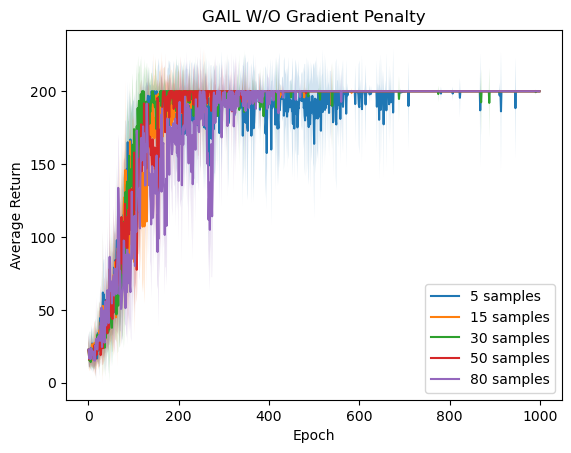

In [12]:
nopen_rewards_5_mean = np.mean(nopen_rewards_5, axis=-1)
nopen_reward_5_std = np.std(nopen_rewards_5, axis=-1)
nopen_rewards_15_mean = np.mean(nopen_rewards_15, axis=-1)
nopen_rewards_15_std = np.std(nopen_rewards_15, axis=-1)
nopen_rewards_30_mean = np.mean(nopen_rewards_30, axis=-1)
nopen_rewards_30_std = np.std(nopen_rewards_30, axis=-1)
nopen_rewards_50_mean = np.mean(nopen_rewards_50, axis=-1)
nopen_rewards_50_std = np.std(nopen_rewards_50, axis=-1)
nopen_rewards_80_mean = np.mean(nopen_rewards_80, axis=-1)
nopen_rewards_80_std = np.std(nopen_rewards_80, axis=-1)

plt.figure()
plt.plot(nopen_rewards_5_mean, label='5 samples')
plt.fill_between(np.arange(len(nopen_rewards_5_mean)), nopen_rewards_5_mean-nopen_reward_5_std, nopen_rewards_5_mean+nopen_reward_5_std, alpha=0.2)
plt.plot(nopen_rewards_15_mean, label='15 samples')
plt.fill_between(np.arange(len(nopen_rewards_15_mean)), nopen_rewards_15_mean-nopen_rewards_15_std, nopen_rewards_15_mean+nopen_rewards_15_std, alpha=0.2)
plt.plot(nopen_rewards_30_mean, label='30 samples')
plt.fill_between(np.arange(len(nopen_rewards_30_mean)), nopen_rewards_30_mean-nopen_rewards_30_std, nopen_rewards_30_mean+nopen_rewards_30_std, alpha=0.2)
plt.plot(nopen_rewards_50_mean, label='50 samples')
plt.fill_between(np.arange(len(nopen_rewards_50_mean)), nopen_rewards_50_mean-nopen_rewards_50_std, nopen_rewards_50_mean+nopen_rewards_50_std, alpha=0.2)
plt.plot(nopen_rewards_80_mean, label='80 samples')
plt.fill_between(np.arange(len(nopen_rewards_80_mean)), nopen_rewards_80_mean-nopen_rewards_80_std, nopen_rewards_80_mean+nopen_rewards_80_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Average Return')
plt.title('GAIL W/O Gradient Penalty')
plt.legend()
plt.show()

In [16]:
# Use Gradient Penalty

"""Using 50 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = True,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)
Manager.sample_expert_data(n_episode=10,n_samples=50)
Manager.train_gail()
pen_rewards_50 = np.array(Manager.eval_rewards)

GAIL_Training: 100%|██████████| 1000/1000 [06:33<00:00,  2.54it/s, Avg. Return=200]


In [17]:
"""Using 80 samples"""
env = gym.make('CartPole-v0')
Manager = TrainManager(
    env = env,
    actor_lr = 1e-3,
    critic_lr = 5e-3,
    gamma = 0.98,
    advantage_lambda = 0.95,
    clip_epsilon = 0.2,
    ppo_train_iters = 5, 
    ppo_batch_size = 64,
    gail_train_epoch_num = 1000,
    discriminator_train_iters = 5,
    discriminator_batch_size = 64,
    use_grad_pen = True,
    d_lr = 1e-3,
    seed = 0,
    device = "cpu" 
)
Manager.sample_expert_data(n_episode=10,n_samples=80)
Manager.train_gail()
pen_rewards_80 = np.array(Manager.eval_rewards)

GAIL_Training: 100%|██████████| 1000/1000 [06:58<00:00,  2.39it/s, Avg. Return=200]


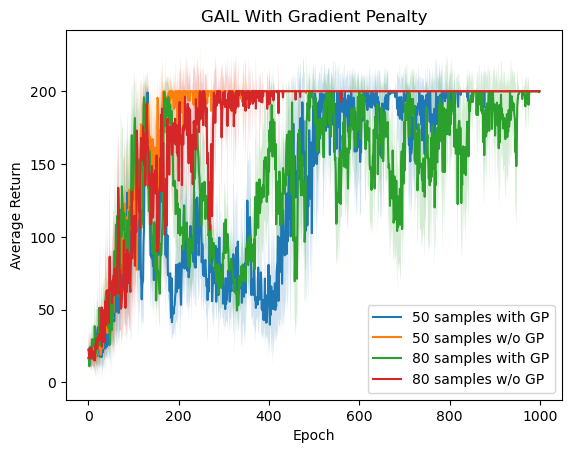

In [19]:
pen_rewards_50_mean = np.mean(pen_rewards_50, axis=-1)
pen_reward_50_std = np.std(pen_rewards_50, axis=-1)
pen_rewards_80_mean = np.mean(pen_rewards_80, axis=-1)
pen_rewards_80_std = np.std(pen_rewards_80, axis=-1)

plt.figure()
plt.plot(pen_rewards_50_mean, label='50 samples with GP')
plt.fill_between(np.arange(len(pen_rewards_50_mean)), pen_rewards_50_mean-pen_reward_50_std, pen_rewards_50_mean+pen_reward_50_std, alpha=0.2)
plt.plot(nopen_rewards_50_mean, label='50 samples w/o GP')
plt.fill_between(np.arange(len(nopen_rewards_50_mean)), nopen_rewards_50_mean-nopen_rewards_50_std, nopen_rewards_50_mean+nopen_rewards_50_std, alpha=0.2)
plt.plot(pen_rewards_80_mean, label='80 samples with GP')
plt.fill_between(np.arange(len(pen_rewards_80_mean)), pen_rewards_80_mean-pen_rewards_80_std, pen_rewards_80_mean+pen_rewards_80_std, alpha=0.2)
plt.plot(nopen_rewards_80_mean, label='80 samples w/o GP')
plt.fill_between(np.arange(len(nopen_rewards_80_mean)), nopen_rewards_80_mean-nopen_rewards_80_std, nopen_rewards_80_mean+nopen_rewards_80_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Average Return')
plt.title('GAIL With Gradient Penalty')
plt.legend()
plt.show()